# Cat Detector 


# Requirements

In [18]:
import cv2
import os
import matplotlib.pyplot as plt


# Loading Image

In [19]:
# Define the path to the image file using os.path.join for cross-platform compatibility
image_address = os.path.join("images", "image.webp")

# Define the path to the Haar Cascade model file using os.path.join for cross-platform compatibility
model = os.path.join("models", "haarcascade_frontalcatface_extended.xml")

# Read the input image from the specified path
image = cv2.imread(image_address)

# Convert the image from BGR to RGB format (as OpenCV uses BGR by default and Matplotlib uses RGB)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


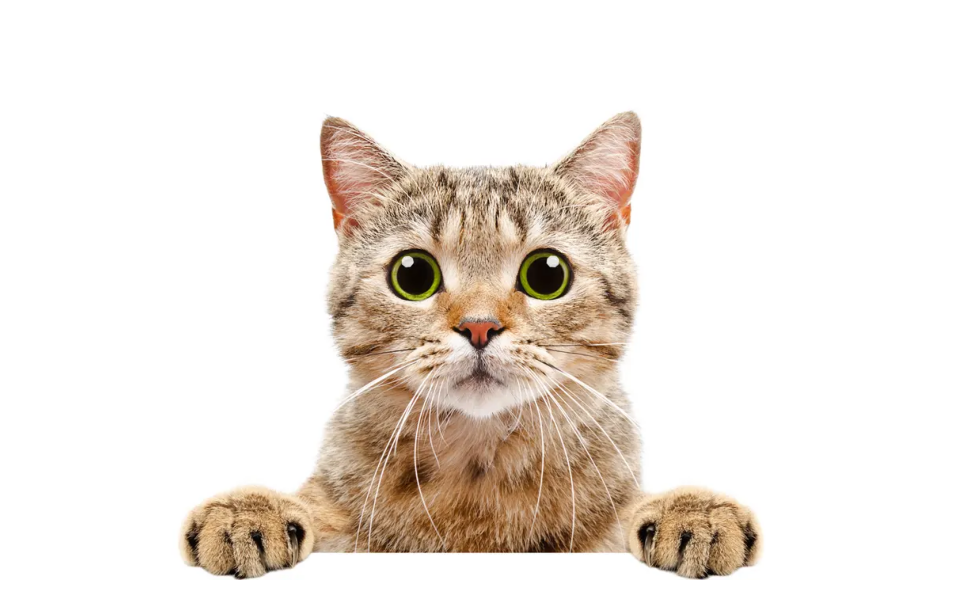

In [20]:
# Create a figure with specified size to display the image
plt.figure(figsize=(10, 6))

# Display the image using Matplotlib
plt.imshow(image)

# Turn off the axis for a cleaner look
plt.axis("off")

# Show the figure
plt.tight_layout()
plt.show()


# Detecting Cat

In [21]:
def detect_cat(image):
    # Load the Haar Cascade model for cat face detection
    detector = cv2.CascadeClassifier(model)

    # Detect cat faces in the image using the loaded model
    # scaleFactor: Parameter specifying how much the image size is reduced at each image scale
    # minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it
    # minSize: Minimum possible object size. Objects smaller than this are ignored.
    rects = detector.detectMultiScale(image, scaleFactor=1.01, minNeighbors=2, minSize=(180, 180))

    # Iterate over the detected rectangles (bounding boxes for cat faces)
    for (i, (x, y, w, h)) in enumerate(rects):
        # Draw a rectangle around the detected cat face
        cv2.rectangle(image, (x, y), (x + w, y + h), (38, 94, 158), 2, 4)
        # Annotate the image with the text 'Cat #N' above the rectangle
        cv2.putText(image, f"Cat {i+1}", (x, y-10), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1.2, (0, 150, 255), 2, cv2.LINE_AA)

    return image


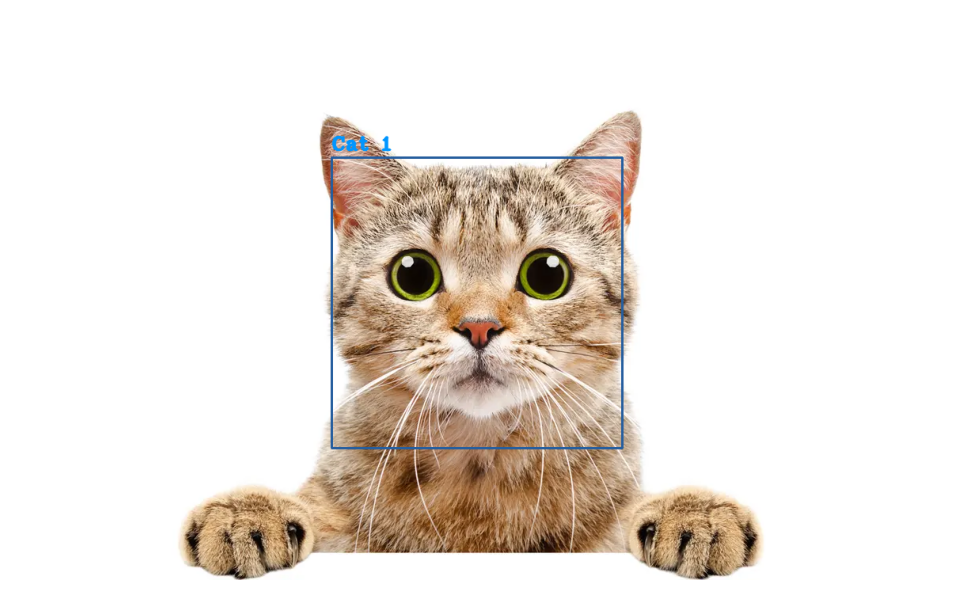

In [22]:
image = detect_cat(image)
# Create a figure with specified size to display the image
plt.figure(figsize=(10, 6))

# Display the image using Matplotlib
plt.imshow(image)

# Turn off the axis for a cleaner look
plt.axis("off")

# Show the figure
plt.tight_layout()
plt.show()


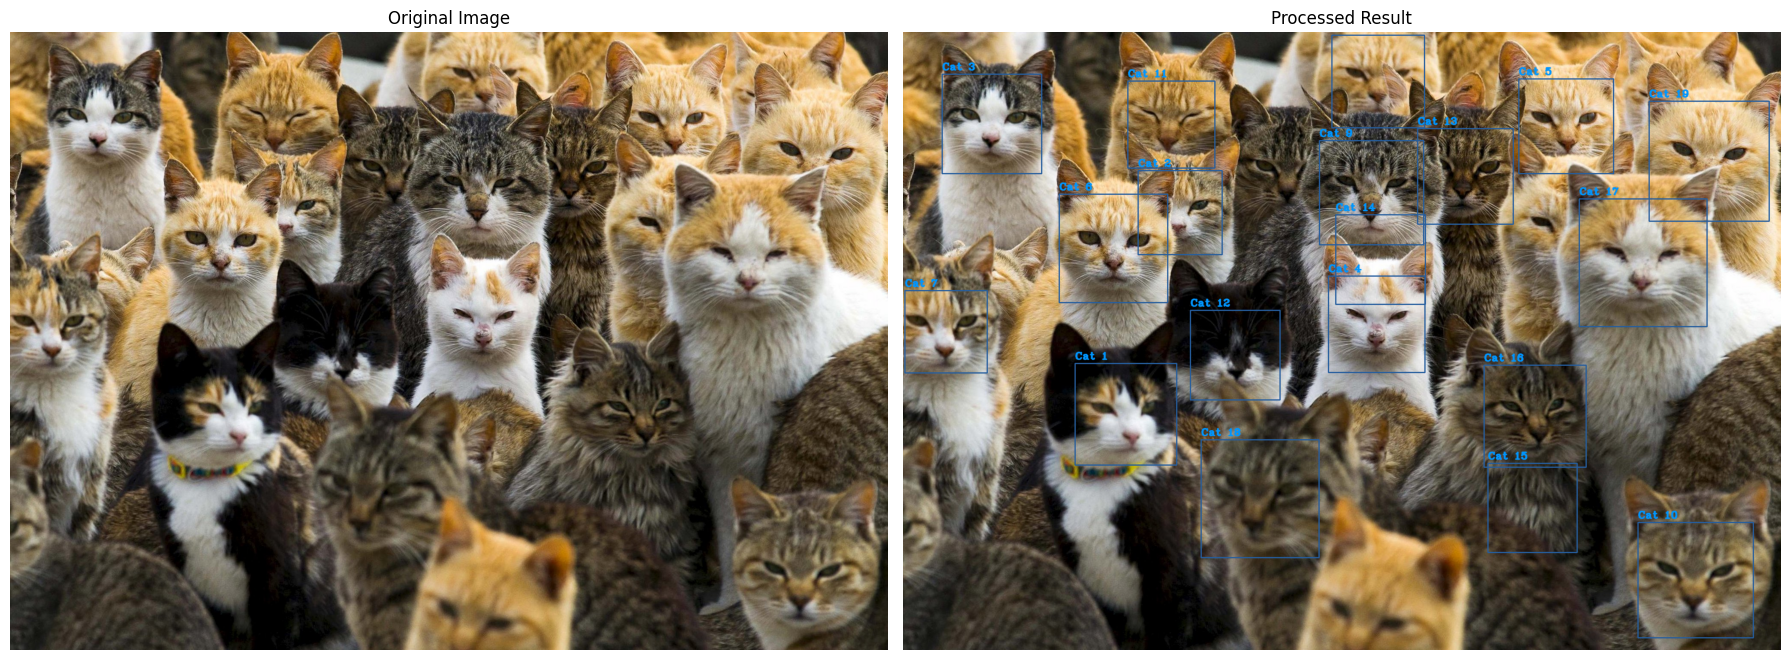

In [23]:
image_address = os.path.join("images", "image.jpg")
image = cv2.imread(image_address)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

result = detect_cat(image)

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Processed Result")
plt.axis("off")

plt.tight_layout()
plt.show()
